In [ ]:

# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
from pathlib import Path
import os
import re
import json
import traceback
import warnings
import subprocess
import sys
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1) Path to the final Main notebook
# -----------------------------------------------------------------------------
Main_NOTEBOOK_PATH = Path("Single.ipynb")
AUTO_FIND_Main_NOTEBOOK = False



RAW_DATASET_FILES = [
    # EDIT THESE PATHS:
    # "output/single_datasets_report_only/Pre_M1.csv",
    # "output/single_datasets_report_only/Post1_M1.csv",
    # "output/single_datasets_report_only/Post2_M1.csv",
    # "output/single_datasets_report_only/ADC_M1.csv",
    # "output/single_datasets_report_only/T2_M1.csv",
]

AUTO_DISCOVER_DATASETS = True
SOURCE_DATASET_DIR = Path("../Dataset/Breast-Data/Mask1")
DATASET_GLOB_PATTERN = "*.csv"

REQUIRE_EXACTLY_FIVE_DATASETS = True

# -----------------------------------------------------------------------------
# 3) Column names
# -----------------------------------------------------------------------------
LABEL_COL = "Label"
GROUP_COL = "PatientID"

LABEL_CANDIDATE_COLUMNS = [
    "Label", "label", "Class", "class", "Target", "target", "Malignancy", "Diagnosis", "diagnosis"
]

NON_FEATURE_COLUMNS = [
    "Label", "label", "PatientID", "Patient_ID", "ID", "CaseID", "Case_ID",
    "INFO_NameOfRoi", "NameOfRoi", "ROI", "ROI_Name", "LesionID", "Lesion_ID"
]

# -----------------------------------------------------------------------------
# 4) Output locations
# -----------------------------------------------------------------------------
SINGLE_STANDARDIZED_DATASET_DIR = Path("output/all_single_datasets_standardized")
BATCH_ROOT = Path("nested_cv_outputs_single_dataset_batch_smote_compare")
BATCH_RUN_ROOT = Path("batch_single_dataset_runner_artifacts_smote_compare")

EXECUTED_NOTEBOOK_DIR = BATCH_RUN_ROOT / "executed_Main_notebooks_on_single_datasets"
SUMMARY_DIR = BATCH_RUN_ROOT / "summary_tables"

for p in [SINGLE_STANDARDIZED_DATASET_DIR, BATCH_ROOT, BATCH_RUN_ROOT, EXECUTED_NOTEBOOK_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 5) Notebook execution options
# -----------------------------------------------------------------------------
EXECUTE_Main_NOTEBOOKS = True
SKIP_EXISTING_SUCCESSFUL_RUNS = False
OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False
KERNEL_NAME = "python3"
NOTEBOOK_TIMEOUT_SECONDS = 43200  # 12 hours per notebook cell
PROCESS_TIMEOUT_SECONDS = 46800   # 13 hours for each complete child run


ADD_PARAMETERS_TAG_TO_Main = True


PATCH_FINAL_ZIP_OUTPUT_IN_PLACE = True

print("Configuration loaded.")
print(f"SINGLE_STANDARDIZED_DATASET_DIR: {SINGLE_STANDARDIZED_DATASET_DIR.resolve()}")
print(f"BATCH_ROOT:                      {BATCH_ROOT.resolve()}")
print(f"SUMMARY_DIR:                     {SUMMARY_DIR.resolve()}")
print(f"COMPARE_SMOTE_OPTIONS:           {COMPARE_SMOTE_OPTIONS}")
print(f"RUN_SMOTE_ABLATION:              {RUN_SMOTE_ABLATION}")
print(f"RUN_SMOTE_VS_BASELINE_COMPARISON:{RUN_SMOTE_VS_BASELINE_COMPARISON}")


Configuration loaded.
SINGLE_STANDARDIZED_DATASET_DIR: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized
BATCH_ROOT:                      /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare
SUMMARY_DIR:                     /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/batch_single_dataset_runner_artifacts_smote_compare/summary_tables
COMPARE_SMOTE_OPTIONS:           True
RUN_SMOTE_ABLATION:              False
RUN_SMOTE_VS_BASELINE_COMPARISON:False


In [2]:

# =============================================================================
# CELL 2 — ONE-TIME DEPENDENCY CHECK
# =============================================================================

def ensure_import(import_name, pip_name=None):
    import importlib.util
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {import_name}")

ensure_import("nbformat", "nbformat")
ensure_import("papermill", "papermill")
ensure_import("statsmodels", "statsmodels")
ensure_import("imblearn", "imbalanced-learn")

import nbformat
import papermill as pm

print("Dependency check completed.")


OK: nbformat
OK: papermill
OK: statsmodels
OK: imblearn
Dependency check completed.


In [3]:

# =============================================================================
# CELL 3 — FILE DISCOVERY AND VALIDATION
# =============================================================================

def find_Main_notebook(path: Path) -> Path:
    if path.exists():
        return path.resolve()

    if not AUTO_FIND_Main_NOTEBOOK:
        raise FileNotFoundError(f"Main notebook not found: {path}")

    candidates = []
    for root in [Path.cwd(), Path("/kaggle/input"), Path("/mnt/data")]:
        if root.exists():
            try:
                candidates.extend(root.rglob("Single.ipynb"))
            except Exception:
                pass

    candidates = sorted(set(candidates))
    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find Single.ipynb. Put it next to this notebook or set Main_NOTEBOOK_PATH."
        )

    print("Found Single.ipynb candidates:")
    for c in candidates:
        print("  -", c)

    return candidates[0].resolve()


def discover_dataset_files():
    if len(RAW_DATASET_FILES) > 0:
        files = [Path(x) for x in RAW_DATASET_FILES]
    else:
        if not AUTO_DISCOVER_DATASETS:
            raise ValueError("RAW_DATASET_FILES is empty and AUTO_DISCOVER_DATASETS=False.")
        if not SOURCE_DATASET_DIR.exists():
            raise FileNotFoundError(
                f"SOURCE_DATASET_DIR does not exist: {SOURCE_DATASET_DIR}\n"
                "Either create this folder or fill RAW_DATASET_FILES manually."
            )
        files = sorted(SOURCE_DATASET_DIR.glob(DATASET_GLOB_PATTERN))

    filtered = []
    for p in files:
        stem_lower = p.stem.lower()
        if any(x in stem_lower for x in [
            "Main", "triple", "quad", "all5", "all_5", "summary", "comparison", "random_label"
        ]):
            continue
        filtered.append(p)

    files = [p.resolve() for p in filtered]

    missing = [str(p) for p in files if not p.exists()]
    if missing:
        raise FileNotFoundError("These dataset files were not found:\n" + "\n".join(missing))

    if REQUIRE_EXACTLY_FIVE_DATASETS and len(files) != 5:
        raise ValueError(
            f"Expected exactly 5 base single datasets, but found {len(files)}.\n"
            "Files found:\n" + "\n".join(str(p) for p in files) + "\n\n"
            "Fix RAW_DATASET_FILES or SOURCE_DATASET_DIR."
        )

    if len(files) == 0:
        raise ValueError("No dataset files found.")

    return files


Main_NOTEBOOK_PATH = find_Main_notebook(Main_NOTEBOOK_PATH)
DATASET_FILES = discover_dataset_files()

print("Main notebook:")
print(" ", Main_NOTEBOOK_PATH)

print("\nSingle datasets to run:")
for i, f in enumerate(DATASET_FILES, start=1):
    print(f"{i}. {f}")

print(f"\nNumber of single-dataset runs: {len(DATASET_FILES)}")

# -----------------------------------------------------------------------------
# Validate that the selected notebook is the actual batch-safe version.
# -----------------------------------------------------------------------------
_target_nb = nbformat.read(
    Main_NOTEBOOK_PATH,
    as_version=4,
)

_target_sources = [
    cell.source
    for cell in _target_nb.cells
    if cell.cell_type == "code"
]

_has_batch_parameters = any(
    (
        "IS_BATCH_RUN = False" in source
        and "RUN_DESCRIPTIVE_PLOTS = True" in source
    )
    for source in _target_sources
)

_has_morphology_guard = any(
    "BATCH-SAFE GUARD — MORPHOLOGICAL DESCRIPTION" in source
    for source in _target_sources
)

_has_execution_resolution = any(
    (
        "ANY_BATCH_RUN = bool(" in source
        and "RUN_DESCRIPTIVE_PLOTS = False" in source
    )
    for source in _target_sources
)

if not (
    _has_batch_parameters
    and _has_morphology_guard
    and _has_execution_resolution
):
    raise RuntimeError(
        "The selected main notebook is not the batch-safe final version.\n\n"
        f"Selected notebook:\n{Main_NOTEBOOK_PATH}\n\n"
        "Place 'Single_batch_safe_final.ipynb' next to this Batch Runner "
        "and run the notebook again from the first cell."
    )

print("\nBatch-safe notebook validation: PASSED")
print("Target notebook used by Papermill:")
print(" ", Main_NOTEBOOK_PATH)



Main notebook:
  /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/Single_batch_safe_final.ipynb

Single datasets to run:
1. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/ADC_M1.csv
2. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post1_M1.csv
3. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post2_M1.csv
4. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Pre_M1.c

In [4]:

# =============================================================================
# CELL 4 — DATASET READING, TAGGING, AND STANDARDIZATION FUNCTIONS
# =============================================================================

def clean_tag_from_path(path):
    """Create a compact dataset tag from filename."""
    stem = Path(path).stem
    suffixes = [
        "_Cleaned", "_cleaned", "_M1_Main", "_Main", "_M1",
        "_triple", "_triplewise", "_quad", "_quadwise", "_all5", "_all_5", "_allfive"
    ]
    changed = True
    while changed:
        changed = False
        for s in suffixes:
            if stem.endswith(s):
                stem = stem[: -len(s)]
                changed = True
    stem = re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")
    return stem


def read_csv_flexible(path):
    """Read comma-, semicolon-, tab-, or whitespace-separated CSV robustly."""
    path = Path(path)
    attempts = [
        dict(sep=None, engine="python"),
        dict(sep=","),
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=r"\s+", engine="python"),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not read CSV correctly: {path}\nLast error: {last_error}")


def normalize_column_lookup(df):
    return {str(c).strip().lower(): c for c in df.columns}


def resolve_label_column(df):
    lookup = normalize_column_lookup(df)
    for c in LABEL_CANDIDATE_COLUMNS:
        key = str(c).strip().lower()
        if key in lookup:
            return lookup[key]
    raise ValueError(
        "Could not find label column. Tried: " + ", ".join(LABEL_CANDIDATE_COLUMNS)
    )


def drop_unnamed_index_columns(df):
    drop_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df


def count_feature_columns(df):
    label_col = LABEL_COL if LABEL_COL in df.columns else resolve_label_column(df)
    non_feature_lower = {str(c).strip().lower() for c in NON_FEATURE_COLUMNS}
    feature_cols = []
    for c in df.columns:
        if c == label_col:
            continue
        if str(c).strip().lower() in non_feature_lower:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            feature_cols.append(c)
    return feature_cols


def standardize_single_dataset(path):
    """Read one dataset, enforce comma CSV and Label column, then save standardized copy."""
    path = Path(path).resolve()
    tag = clean_tag_from_path(path)
    df = read_csv_flexible(path)
    df = drop_unnamed_index_columns(df)

    label_source_col = resolve_label_column(df)
    if label_source_col != LABEL_COL:
        if LABEL_COL in df.columns:
            raise ValueError(
                f"Both {LABEL_COL!r} and {label_source_col!r} exist. Please resolve duplicate label columns."
            )
        df = df.rename(columns={label_source_col: LABEL_COL})

    # Put Label as the last column for consistency.
    cols = [c for c in df.columns if c != LABEL_COL] + [LABEL_COL]
    df = df[cols]

    label_counts = df[LABEL_COL].value_counts(dropna=False).to_dict()
    feature_cols = count_feature_columns(df)

    out_path = SINGLE_STANDARDIZED_DATASET_DIR / f"{tag}_single_standardized.csv"
    df.to_csv(out_path, index=False)

    meta = {
        "Single_Tag": tag,
        "Dataset": tag,
        "Original_Input_File": str(path),
        "Single_Input_File": str(out_path.resolve()),
        "Rows": int(df.shape[0]),
        "Columns_Total": int(df.shape[1]),
        "N_Features_Total": int(len(feature_cols)),
        "Label_Column": LABEL_COL,
        "Label_Counts": json.dumps({str(k): int(v) for k, v in label_counts.items()}, ensure_ascii=False),
        "Status": "dataset_standardized",
        "Error": "",
    }
    return out_path.resolve(), meta


In [5]:

# =============================================================================
# CELL 5 — STANDARDIZE ALL SINGLE DATASETS
# =============================================================================

single_dataset_rows = []
single_dataset_paths = []

for dataset_path in DATASET_FILES:
    try:
        out_path, meta = standardize_single_dataset(dataset_path)
        single_dataset_paths.append(out_path)
        single_dataset_rows.append(meta)
        print(
            f" Standardized: {meta['Single_Tag']} | "
            f"rows={meta['Rows']} | features={meta['N_Features_Total']} | labels={meta['Label_Counts']}"
        )
    except Exception as e:
        tag = clean_tag_from_path(dataset_path)
        failed_meta = {
            "Single_Tag": tag,
            "Dataset": tag,
            "Original_Input_File": str(Path(dataset_path).resolve()),
            "Single_Input_File": "",
            "Rows": np.nan,
            "Columns_Total": np.nan,
            "N_Features_Total": np.nan,
            "Label_Column": LABEL_COL,
            "Label_Counts": "",
            "Status": "dataset_standardization_failed",
            "Error": str(e),
        }
        single_dataset_rows.append(failed_meta)
        print(f" Failed to standardize dataset: {tag}")
        print(str(e))

df_single_datasets = pd.DataFrame(single_dataset_rows)
dataset_log_path = SUMMARY_DIR / "single_dataset_standardization_log.csv"
df_single_datasets.to_csv(dataset_log_path, index=False)

print("\nSaved dataset standardization log:")
print(dataset_log_path)

display(df_single_datasets)


 Standardized: ADC | rows=114 | features=144 | labels={"1": 64, "0": 50}
 Standardized: Post1 | rows=116 | features=145 | labels={"1": 64, "0": 52}
 Standardized: Post2 | rows=117 | features=145 | labels={"1": 65, "0": 52}
 Standardized: Pre | rows=117 | features=145 | labels={"1": 65, "0": 52}
 Standardized: T2 | rows=117 | features=145 | labels={"1": 65, "0": 52}

Saved dataset standardization log:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_standardization_log.csv


,Single_Tag,Dataset,Original_Input_File,Single_Input_File,Rows,Columns_Total,N_Features_Total,Label_Column,Label_Counts,Status,Error
0,ADC,ADC,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,114,147,144,Label,"{""1"": 64, ""0"": 50}",dataset_standardized,
1,Post1,Post1,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,116,148,145,Label,"{""1"": 64, ""0"": 52}",dataset_standardized,
2,Post2,Post2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,117,148,145,Label,"{""1"": 65, ""0"": 52}",dataset_standardized,
3,Pre,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,117,148,145,Label,"{""1"": 65, ""0"": 52}",dataset_standardized,
4,T2,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,117,148,145,Label,"{""1"": 65, ""0"": 52}",dataset_standardized,


In [6]:

# =============================================================================
# CELL 6 — RUN THE SAME Single.ipynb WITH EACH SINGLE DATASET VIA PAPERMILL
# =============================================================================


def ensure_Main_accepts_papermill_parameters(nb_path):
    nb_path = Path(nb_path)
    nb = nbformat.read(nb_path, as_version=4)
    if len(nb.cells) == 0:
        raise ValueError("Single.ipynb has no cells.")

    changed = False

    if ADD_PARAMETERS_TAG_TO_Main:
        tags = list(nb.cells[0].metadata.get("tags", []))
        if "parameters" not in tags:
            tags.append("parameters")
            nb.cells[0].metadata["tags"] = tags
            changed = True
            print("Added 'parameters' tag to cell 0 of Single.ipynb.")

    if PATCH_FINAL_ZIP_OUTPUT_IN_PLACE:
        for cell in nb.cells:
            if cell.cell_type != "code":
                continue
            src = cell.source
            if "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)" in src:
                new_src = src.replace(
                    "staging_dir = os.path.join(base_working_dir, 'final_outputs')",
                    "staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')"
                )
                new_src = new_src.replace(
                    "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)",
                    "output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)"
                )
                if new_src != src:
                    cell.source = new_src
                    changed = True
                    print("Patched final zip output path to be single-dataset-specific.")

    if changed:
        try:
            nbformat.write(nb, nb_path)
            print("Single.ipynb updated in place for papermill parameters.")
            return nb_path
        except Exception as e:
            fallback_path = BATCH_RUN_ROOT / "Main_parameter_ready_for_single_dataset_run.ipynb"
            nbformat.write(nb, fallback_path)
            print(f"Could not write to original Single.ipynb: {e}")
            print(f"Using one reusable parameter-ready copy instead: {fallback_path}")
            return fallback_path.resolve()
    else:
        print("Single.ipynb already parameter-ready.")
        return nb_path


def final_single_summary_exists(single_tag):
    summary_path = (
        BATCH_ROOT
        / single_tag
        / "fs_method_comparison"
        / "_comparison_summary"
        / "publication_fs_comparison_best_per_method.csv"
    )
    return summary_path.exists()


def build_Main_parameters_for_single(single_input_file, single_tag):
    single_input_file = Path(single_input_file).resolve()
    output_dir = Path("output/cleaned_single_datasets_smote_compare") / single_tag
    dataset_output_root = BATCH_ROOT / single_tag
    cleaned_dataset_path = output_dir / f"{single_input_file.stem}_Cleaned.csv"

    return {
        "INPUT_FILE": str(
            single_input_file
        ),

        "DATASET_TAG": str(
            single_tag
        ),

        "BATCH_ROOT": str(
            BATCH_ROOT
        ),

        "OUTPUT_DIR": str(
            output_dir
        ),

        "TARGET_COLUMN": str(
            LABEL_COL
        ),

        "DATASET_OUTPUT_ROOT": str(
            dataset_output_root
        ),

        "CLEANED_DATASET_PATH": str(
            cleaned_dataset_path
        ),

        "OVERWRITE_FS_RUNS": bool(
            OVERWRITE_FS_RUNS
        ),

        "COMPARE_SMOTE_OPTIONS": bool(
            COMPARE_SMOTE_OPTIONS
        ),

        "TARGET_ABLATION": None,

        "RUN_SMOTE_ABLATION": bool(
            RUN_SMOTE_ABLATION
        ),

        "RUN_SMOTE_VS_BASELINE_COMPARISON": bool(
            RUN_SMOTE_VS_BASELINE_COMPARISON
        ),

        # -------------------------------------------------------------
        # Batch execution flags
        # -------------------------------------------------------------
        "IS_BATCH_RUN": True,
        "PAPERMILL_BATCH_RUN": True,
        "BATCH_MODE": True,

        # -------------------------------------------------------------
        # Plot controls
        # -------------------------------------------------------------
        "RUN_PUBLICATION_PLOTS": False,
        "RUN_DESCRIPTIVE_PLOTS": False,

        # Raw Mask1 files are not required in batch
        "MASK1_SOURCE_DIR": None,
    }



Main_EXEC_NOTEBOOK_PATH = ensure_Main_accepts_papermill_parameters(Main_NOTEBOOK_PATH)

import time

# =============================================================================
# ISOLATED PAPERMILL SUBPROCESS EXECUTION
# =============================================================================
# Each dataset runs in a separate Python process. Therefore, interruption or
# failure of the child Jupyter kernel cannot close the Batch Runner's ZMQ socket.

PAPERMILL_CHILD_CODE = r"""
import json
import sys

import papermill as pm

input_path = sys.argv[1]
output_path = sys.argv[2]
params_path = sys.argv[3]
kernel_name = sys.argv[4]
cwd = sys.argv[5]
execution_timeout_text = sys.argv[6]

with open(params_path, "r", encoding="utf-8") as handle:
    parameters = json.load(handle)

execution_timeout = (
    None
    if execution_timeout_text == "None"
    else int(execution_timeout_text)
)

pm.execute_notebook(
    input_path=input_path,
    output_path=output_path,
    parameters=parameters,
    kernel_name=kernel_name,
    cwd=cwd,
    progress_bar=True,
    log_output=True,
    request_save_on_cell_execute=True,
    execution_timeout=execution_timeout,
)
"""


def terminate_child_process(process, grace_seconds=10):
    if process is None or process.poll() is not None:
        return

    process.terminate()

    try:
        process.wait(timeout=grace_seconds)
    except subprocess.TimeoutExpired:
        process.kill()
        process.wait(timeout=grace_seconds)


run_rows = []

if EXECUTE_Main_NOTEBOOKS:
    for _, row in df_single_datasets.iterrows():

        if row["Status"] != "dataset_standardized":
            run_rows.append({
                "Single_Tag": row["Single_Tag"],
                "Run_Status": "not_run_dataset_standardization_failed",
                "Executed_Notebook": "",
                "Parameters_File": "",
                "Stdout_Log": "",
                "Stderr_Log": "",
                "Return_Code": np.nan,
                "Error": row.get("Error", ""),
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        single_tag = row["Single_Tag"]
        single_input_file = row["Single_Input_File"]

        if SKIP_EXISTING_SUCCESSFUL_RUNS and final_single_summary_exists(single_tag):
            print(f"Skipping existing successful run: {single_tag}")

            run_rows.append({
                "Single_Tag": single_tag,
                "Run_Status": "skipped_existing",
                "Executed_Notebook": "",
                "Parameters_File": "",
                "Stdout_Log": "",
                "Stderr_Log": "",
                "Return_Code": 0,
                "Error": "",
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        params = build_Main_parameters_for_single(
            single_input_file,
            single_tag,
        )

        executed_path = (
            EXECUTED_NOTEBOOK_DIR
            / f"{single_tag}__Main_executed_on_single_dataset.ipynb"
        )
        params_path = (
            EXECUTED_NOTEBOOK_DIR
            / f"{single_tag}__papermill_parameters.json"
        )
        stdout_path = (
            EXECUTED_NOTEBOOK_DIR
            / f"{single_tag}__papermill_stdout.log"
        )
        stderr_path = (
            EXECUTED_NOTEBOOK_DIR
            / f"{single_tag}__papermill_stderr.log"
        )

        params_path.write_text(
            json.dumps(params, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )

        command = [
            sys.executable,
            "-c",
            PAPERMILL_CHILD_CODE,
            str(Main_EXEC_NOTEBOOK_PATH),
            str(executed_path),
            str(params_path),
            str(KERNEL_NAME),
            str(Path.cwd()),
            (
                "None"
                if NOTEBOOK_TIMEOUT_SECONDS is None
                else str(NOTEBOOK_TIMEOUT_SECONDS)
            ),
        ]

        started = datetime.now().isoformat(timespec="seconds")

        print("\n" + "=" * 100)
        print(f"RUNNING SINGLE DATASET: {single_tag}")
        print("Input:", single_input_file)
        print("Output root:", params["DATASET_OUTPUT_ROOT"])
        print("Executed notebook:", executed_path)
        print("Stdout log:", stdout_path)
        print("Stderr log:", stderr_path)
        print("=" * 100)

        process = None

        try:
            # Stream child output live to the notebook while also saving it.
            #
            # stderr is merged into stdout because Papermill/tqdm commonly writes
            # progress information to stderr. This makes cell progress visible
            # immediately in the Batch Runner, similar to direct pm.execute_notebook.
            with stdout_path.open(
                "w",
                encoding="utf-8",
                buffering=1,
            ) as live_log_handle:

                process = subprocess.Popen(
                    command,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.STDOUT,
                    cwd=str(Path.cwd()),
                    text=True,
                    bufsize=1,
                    universal_newlines=True,
                )

                process_start_time = time.monotonic()

                while True:
                    if process.stdout is None:
                        break

                    line = process.stdout.readline()

                    if line:
                        # Save the exact child output.
                        live_log_handle.write(line)
                        live_log_handle.flush()

                        # Show live progress in the current notebook.
                        print(
                            f"[{single_tag}] {line}",
                            end="",
                            flush=True,
                        )

                    elif process.poll() is not None:
                        break

                    if (
                        PROCESS_TIMEOUT_SECONDS is not None
                        and (
                            time.monotonic()
                            - process_start_time
                        ) > PROCESS_TIMEOUT_SECONDS
                    ):
                        raise subprocess.TimeoutExpired(
                            cmd=command,
                            timeout=PROCESS_TIMEOUT_SECONDS,
                        )

                return_code = process.wait()

            # Keep a separate stderr-path file for compatibility with the
            # existing run-log schema. Child stderr has already been merged
            # into the live stdout log above.
            stderr_path.write_text(
                (
                    "Child stderr was merged into the live stdout log:\n"
                    f"{stdout_path}\n"
                ),
                encoding="utf-8",
            )

            finished = datetime.now().isoformat(timespec="seconds")

            if return_code == 0:
                run_status = "completed"
                error_text = ""
                print(f"Completed: {single_tag}")
            else:
                run_status = "failed"
                error_text = (
                    f"Papermill child process exited with return code "
                    f"{return_code}. See stderr log: {stderr_path}"
                )
                print(f"Failed: {single_tag}")
                print(error_text)

            run_rows.append({
                "Single_Tag": single_tag,
                "Run_Status": run_status,
                "Executed_Notebook": (
                    str(executed_path)
                    if executed_path.exists()
                    else ""
                ),
                "Parameters_File": str(params_path),
                "Stdout_Log": str(stdout_path),
                "Stderr_Log": str(stderr_path),
                "Return_Code": int(return_code),
                "Error": error_text,
                "Started_At": started,
                "Finished_At": finished,
            })

        except subprocess.TimeoutExpired:
            terminate_child_process(process)

            finished = datetime.now().isoformat(timespec="seconds")
            error_text = (
                f"Child process exceeded PROCESS_TIMEOUT_SECONDS="
                f"{PROCESS_TIMEOUT_SECONDS}."
            )

            run_rows.append({
                "Single_Tag": single_tag,
                "Run_Status": "timeout",
                "Executed_Notebook": (
                    str(executed_path)
                    if executed_path.exists()
                    else ""
                ),
                "Parameters_File": str(params_path),
                "Stdout_Log": str(stdout_path),
                "Stderr_Log": str(stderr_path),
                "Return_Code": np.nan,
                "Error": error_text,
                "Started_At": started,
                "Finished_At": finished,
            })

            print(f"Timeout: {single_tag}")
            print(error_text)

        except KeyboardInterrupt:
            terminate_child_process(process)

            finished = datetime.now().isoformat(timespec="seconds")

            run_rows.append({
                "Single_Tag": single_tag,
                "Run_Status": "interrupted",
                "Executed_Notebook": (
                    str(executed_path)
                    if executed_path.exists()
                    else ""
                ),
                "Parameters_File": str(params_path),
                "Stdout_Log": str(stdout_path),
                "Stderr_Log": str(stderr_path),
                "Return_Code": np.nan,
                "Error": "Interrupted by user.",
                "Started_At": started,
                "Finished_At": finished,
            })

            print(f"Interrupted: {single_tag}")
            raise

        except BaseException as error:
            terminate_child_process(process)

            finished = datetime.now().isoformat(timespec="seconds")
            error_text = traceback.format_exc()

            fail_path = (
                EXECUTED_NOTEBOOK_DIR
                / f"{single_tag}__FAILED_error.txt"
            )

            fail_path.write_text(
                error_text,
                encoding="utf-8",
            )

            run_rows.append({
                "Single_Tag": single_tag,
                "Run_Status": "failed_runner_exception",
                "Executed_Notebook": (
                    str(executed_path)
                    if executed_path.exists()
                    else ""
                ),
                "Parameters_File": str(params_path),
                "Stdout_Log": str(stdout_path),
                "Stderr_Log": str(stderr_path),
                "Return_Code": np.nan,
                "Error": str(error),
                "Started_At": started,
                "Finished_At": finished,
            })

            print(f"Runner exception: {single_tag}")
            print(str(error))

else:
    print(
        "EXECUTE_Main_NOTEBOOKS=False. "
        "Datasets were standardized but the main notebook was not executed."
    )

    for _, row in df_single_datasets.iterrows():
        run_rows.append({
            "Single_Tag": row["Single_Tag"],
            "Run_Status": "not_executed",
            "Executed_Notebook": "",
            "Parameters_File": "",
            "Stdout_Log": "",
            "Stderr_Log": "",
            "Return_Code": np.nan,
            "Error": "",
            "Started_At": "",
            "Finished_At": "",
        })


df_run_log = pd.DataFrame(run_rows)

run_log_path = (
    SUMMARY_DIR
    / "single_dataset_notebook_run_log.csv"
)

df_run_log.to_csv(
    run_log_path,
    index=False,
)

print("\nRun log saved:")
print(run_log_path)

display(df_run_log)


Single.ipynb already parameter-ready.

RUNNING SINGLE DATASET: ADC
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized/ADC_single_standardized.csv
Output root: nested_cv_outputs_single_dataset_batch_smote_compare/ADC
Executed notebook: batch_single_dataset_runner_artifacts_smote_compare/executed_Main_notebooks_on_single_datasets/ADC__Main_executed_on_single_dataset.ipynb
Stdout log: batch_single_dataset_runner_artifacts_smote_compare/executed_Main_notebooks_on_single_datasets/ADC__papermill_stdout.log
Stderr log: batch_single_dataset_runner_artifacts_smote_compare/executed_Main_notebooks_on_single_datasets/ADC__papermill_stderr.log
[ADC] 
[ADC] Executing: 100%|██████████| 91/91 [10:58<00:00,  7.23s/cell]
Completed: ADC

RUNNING SINGLE DATASET: Post1
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-B

,Single_Tag,Run_Status,Executed_Notebook,Parameters_File,Stdout_Log,Stderr_Log,Return_Code,Error,Started_At,Finished_At
0,ADC,completed,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,0,,2026-07-23T21:14:10,2026-07-23T21:25:09
1,Post1,completed,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,0,,2026-07-23T21:25:09,2026-07-23T21:36:31
2,Post2,completed,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,0,,2026-07-23T21:36:31,2026-07-23T21:47:56
3,Pre,completed,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,0,,2026-07-23T21:47:56,2026-07-23T21:59:50
4,T2,completed,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,batch_single_dataset_runner_artifacts_smote_co...,0,,2026-07-23T21:59:50,2026-07-23T22:10:46


In [7]:

# =============================================================================
# CELL 7 — COLLECT BEST RESULTS FROM ALL SINGLE-DATASET RUNS
# =============================================================================

def read_best_result_for_single(single_tag):
    single_root = BATCH_ROOT / single_tag
    summary_root = single_root / "fs_method_comparison" / "_comparison_summary"

    ranking_path = summary_root / "fs_method_composite_ranking.csv"
    publication_path = summary_root / "publication_fs_comparison_best_per_method.csv"
    best_per_method_path = summary_root / "fs_comparison_best_model_per_method.csv"
    all_models_path = summary_root / "fs_comparison_all_models.csv"

    if publication_path.exists():
        df_source = pd.read_csv(publication_path)
        source_path = publication_path

        if len(df_source) == 0:
            raise RuntimeError(f"Empty publication table: {publication_path}")

        sort_cols = [
            c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC", "Pooled_PR_AUC"]
            if c in df_source.columns
        ]

        if len(sort_cols) == 0:
            raise RuntimeError(
                f"No AUC/PR-AUC columns found in publication table: {publication_path}"
            )

        best = (
            df_source
            .sort_values(sort_cols, ascending=[False] * len(sort_cols))
            .iloc[0]
            .copy()
        )

    elif ranking_path.exists():
        df_source = pd.read_csv(ranking_path)
        source_path = ranking_path

        if len(df_source) == 0:
            raise RuntimeError(f"Empty ranking table: {ranking_path}")

        sort_cols = [
            c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC", "Pooled_PR_AUC"]
            if c in df_source.columns
        ]

        if len(sort_cols) > 0:
            best = (
                df_source
                .sort_values(sort_cols, ascending=[False] * len(sort_cols))
                .iloc[0]
                .copy()
            )
        else:
            best = df_source.iloc[0].copy()


    elif best_per_method_path.exists():
        df_source = pd.read_csv(best_per_method_path)
        source_path = best_per_method_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty best-per-method table: {best_per_method_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    else:
        raise FileNotFoundError(
            f"No comparison summary found for {single_tag}. Expected one of:\n"
            f"  {ranking_path}\n"
            f"  {publication_path}\n"
            f"  {best_per_method_path}"
        )

    result = {"Single_Tag": single_tag, "Result_Source": str(source_path)}

    preferred_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "USE_SMOTE",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Pooled_Bal_Acc",
        "Mean_F1",
        "Pooled_F1",
        "Mean_Specificity",
        "Pooled_Specificity",
        "Avg_Features",
        "N_Unique_Selected_Features",
        "Max_Selection_Count",
        "Mean_Selection_Count",
        "Composite_Rank_Score",
        "Run_Name",
        "Run_Dir",
    ]

    for c in preferred_cols:
        result[c] = best[c] if c in best.index else np.nan

    return result


summary_rows = []
full_best_tables = []
full_all_model_tables = []
smote_delta_best_tables = []
smote_delta_by_model_tables = []

for _, dataset_row in df_single_datasets.iterrows():
    single_tag = dataset_row["Single_Tag"]
    base_info = dataset_row.to_dict()

    if dataset_row["Status"] != "dataset_standardized":
        base_info.update({
            "Final_Status": "not_run_dataset_standardization_failed",
            "Run_Status": "not_run_dataset_standardization_failed",
            "Result_Error": dataset_row.get("Error", ""),
        })
        summary_rows.append(base_info)
        continue

    run_status = "unknown"
    if "df_run_log" in globals() and len(df_run_log) > 0:
        match = df_run_log[df_run_log["Single_Tag"] == single_tag]
        if len(match) > 0:
            run_status = match.iloc[0]["Run_Status"]

    try:
        best_result = read_best_result_for_single(single_tag)
        base_info.update(best_result)
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "success",
            "Result_Error": "",
        })
        summary_rows.append(base_info)

        best_per_method_path = (
            BATCH_ROOT / single_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_best_model_per_method.csv"
        )
        if best_per_method_path.exists():
            df_tmp = pd.read_csv(best_per_method_path)
            df_tmp.insert(0, "Single_Tag", single_tag)
            df_tmp.insert(1, "Dataset", dataset_row["Dataset"])
            full_best_tables.append(df_tmp)

        all_models_path = (
            BATCH_ROOT / single_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_all_models.csv"
        )
        if all_models_path.exists():
            df_tmp = pd.read_csv(all_models_path)
            df_tmp.insert(0, "Single_Tag", single_tag)
            df_tmp.insert(1, "Dataset", dataset_row["Dataset"])
            full_all_model_tables.append(df_tmp)

        smote_delta_best_path = (
            BATCH_ROOT / single_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_smote_vs_no_smote_best_per_method.csv"
        )
        if smote_delta_best_path.exists():
            df_tmp = pd.read_csv(smote_delta_best_path)
            df_tmp.insert(0, "Single_Tag", single_tag)
            df_tmp.insert(1, "Dataset", dataset_row["Dataset"])
            smote_delta_best_tables.append(df_tmp)

        smote_delta_by_model_path = (
            BATCH_ROOT / single_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_smote_vs_no_smote_by_model.csv"
        )
        if smote_delta_by_model_path.exists():
            df_tmp = pd.read_csv(smote_delta_by_model_path)
            df_tmp.insert(0, "Single_Tag", single_tag)
            df_tmp.insert(1, "Dataset", dataset_row["Dataset"])
            smote_delta_by_model_tables.append(df_tmp)

    except Exception as e:
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "result_collection_failed",
            "Result_Error": str(e),
        })
        summary_rows.append(base_info)


df_single_dataset_summary = pd.DataFrame(summary_rows)

if "Mean_AUC" in df_single_dataset_summary.columns:
    df_single_dataset_summary["_sort_auc"] = pd.to_numeric(df_single_dataset_summary["Mean_AUC"], errors="coerce")
    df_single_dataset_summary = df_single_dataset_summary.sort_values(
        ["Final_Status", "_sort_auc"],
        ascending=[False, False],
        na_position="last",
    ).drop(columns=["_sort_auc"]).reset_index(drop=True)

summary_path = SUMMARY_DIR / "single_dataset_summary.csv"
df_single_dataset_summary.to_csv(summary_path, index=False)

print("Main summary saved:")
print(summary_path)

if full_best_tables:
    df_full_best = pd.concat(full_best_tables, ignore_index=True)
    full_best_path = SUMMARY_DIR / "single_dataset_full_best_per_fs_method.csv"
    df_full_best.to_csv(full_best_path, index=False)
    print("Full best-per-FS-method table saved:")
    print(full_best_path)
else:
    df_full_best = pd.DataFrame()

if full_all_model_tables:
    df_full_all_models = pd.concat(full_all_model_tables, ignore_index=True)
    full_all_models_path = SUMMARY_DIR / "single_dataset_full_all_models.csv"
    df_full_all_models.to_csv(full_all_models_path, index=False)
    print("Full all-model table saved:")
    print(full_all_models_path)
else:
    df_full_all_models = pd.DataFrame()

if smote_delta_best_tables:
    df_smote_vs_no_smote_best = pd.concat(smote_delta_best_tables, ignore_index=True)
    smote_best_path = SUMMARY_DIR / "single_dataset_smote_vs_no_smote_best_per_fs_method.csv"
    df_smote_vs_no_smote_best.to_csv(smote_best_path, index=False)
    print("SMOTE vs no-SMOTE best-per-FS-method table saved:")
    print(smote_best_path)
else:
    df_smote_vs_no_smote_best = pd.DataFrame()

if smote_delta_by_model_tables:
    df_smote_vs_no_smote_by_model = pd.concat(smote_delta_by_model_tables, ignore_index=True)
    smote_by_model_path = SUMMARY_DIR / "single_dataset_smote_vs_no_smote_by_model.csv"
    df_smote_vs_no_smote_by_model.to_csv(smote_by_model_path, index=False)
    print("SMOTE vs no-SMOTE by-model table saved:")
    print(smote_by_model_path)
else:
    df_smote_vs_no_smote_by_model = pd.DataFrame()


display_cols = [
    "Single_Tag",
    "Dataset",
    "Rows",
    "N_Features_Total",
    "Label_Counts",
    "Final_Status",
    "FS_METHOD",
    "FS_N_FEATURES",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Result_Error",
]

display(df_single_dataset_summary[[c for c in display_cols if c in df_single_dataset_summary.columns]])


Main summary saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_summary.csv
Full best-per-FS-method table saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_full_best_per_fs_method.csv
Full all-model table saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_full_all_models.csv
SMOTE vs no-SMOTE best-per-FS-method table saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_smote_vs_no_smote_best_per_fs_method.csv
SMOTE vs no-SMOTE by-model table saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_smote_vs_no_smote_by_model.csv


,Single_Tag,Dataset,Rows,N_Features_Total,Label_Counts,Final_Status,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features,Run_Name,Result_Error
0,Post2,Post2,117,145,"{""1"": 65, ""0"": 52}",success,elasticnet_then_mrmr,auto,SVM_RBF,0.789762,0.127252,0.744083,0.876199,0.814623,0.688295,10.8,22,elasticnet_then_mrmr_auto_k_no_smote,
1,Post1,Post1,116,145,"{""1"": 64, ""0"": 52}",success,elasticnet_then_mrmr,auto,KNN,0.767248,0.098168,0.764724,0.798354,0.815028,0.678550,7.2,17,elasticnet_then_mrmr_auto_k_smote,
2,ADC,ADC,114,144,"{""1"": 64, ""0"": 50}",success,mrmr_then_elasticnet_no_corr,auto,SVM_Linear,0.764110,0.080197,0.691250,0.798531,0.720434,0.692643,8.8,29,mrmr_then_elasticnet_no_corr_auto_k_smote,
3,Pre,Pre,117,145,"{""1"": 65, ""0"": 52}",success,mrmr_then_elasticnet_no_corr,auto,LogisticRegression,0.698175,0.070388,0.678698,0.752795,0.739541,0.592121,10.4,34,mrmr_then_elasticnet_no_corr_auto_k_smote,
4,T2,T2,117,145,"{""1"": 65, ""0"": 52}",success,elasticnet_then_mrmr,auto,SVM_RBF,0.674499,0.049438,0.642012,0.708317,0.679084,0.592260,12.4,26,elasticnet_then_mrmr_auto_k_smote,


Publication-style summary saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/publication_single_dataset_summary.csv


,Single_Tag,Dataset,Rows,N_Features_Total,Label_Counts,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,...,Mean_Bal_Acc,Pooled_Bal_Acc,Mean_F1,Pooled_F1,Avg_Features,N_Unique_Selected_Features,Run_Name,Run_Dir,Final_Status,Result_Error
0,Post2,Post2,117,145,"{""1"": 65, ""0"": 52}",elasticnet_then_mrmr,auto,SVM_RBF,0.789762,0.127252,...,0.688295,0.669231,0.694431,0.712121,10.8,22,elasticnet_then_mrmr_auto_k_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,success,
1,Post1,Post1,116,145,"{""1"": 64, ""0"": 52}",elasticnet_then_mrmr,auto,KNN,0.767248,0.098168,...,0.678550,0.704928,0.626352,0.700855,7.2,17,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_single_dataset_batch_smote_c...,success,
2,ADC,ADC,114,144,"{""1"": 64, ""0"": 50}",mrmr_then_elasticnet_no_corr,auto,SVM_Linear,0.764110,0.080197,...,0.692643,0.682500,0.670807,0.683761,8.8,29,mrmr_then_elasticnet_no_corr_auto_k_smote,nested_cv_outputs_single_dataset_batch_smote_c...,success,
3,Pre,Pre,117,145,"{""1"": 65, ""0"": 52}",mrmr_then_elasticnet_no_corr,auto,LogisticRegression,0.698175,0.070388,...,0.592121,0.594231,0.609094,0.635659,10.4,34,mrmr_then_elasticnet_no_corr_auto_k_smote,nested_cv_outputs_single_dataset_batch_smote_c...,success,
4,T2,T2,117,145,"{""1"": 65, ""0"": 52}",elasticnet_then_mrmr,auto,SVM_RBF,0.674499,0.049438,...,0.592260,0.590385,0.585363,0.612903,12.4,26,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_single_dataset_batch_smote_c...,success,


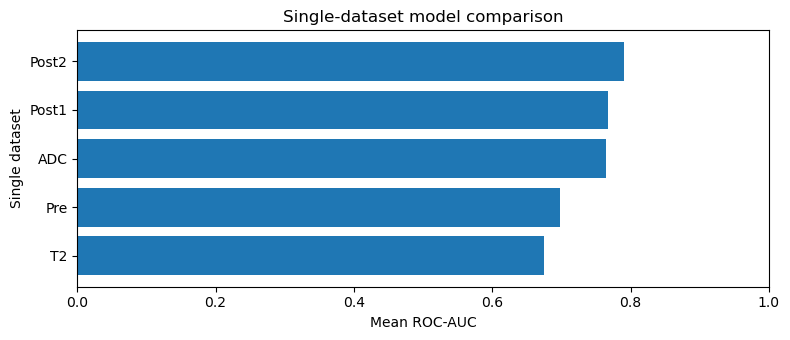

Plot saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/single_dataset_mean_auc_barplot.png
Publication-style SMOTE vs no-SMOTE summary saved:
batch_single_dataset_runner_artifacts_smote_compare/summary_tables/publication_single_dataset_smote_vs_no_smote_summary.csv


,Single_Tag,Dataset,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,Mean_AUC_No_SMOTE,Mean_AUC_SMOTE,Delta_Mean_AUC_SMOTE_minus_No_SMOTE,Pooled_AUC_No_SMOTE,...,Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE,Mean_Bal_Acc_No_SMOTE,Mean_Bal_Acc_SMOTE,Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,Run_Name_No_SMOTE,Run_Name_SMOTE,SMOTE_Effect
0,ADC,ADC,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,LogisticRegression,0.747668,0.731950,-0.015718,0.703125,...,-0.006008,0.689270,0.688978,-2.923977e-04,12.0,12.0,0.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,No_SMOTE_better_or_equal
1,ADC,ADC,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,KNN,LightGBM,0.728058,0.760118,0.032060,0.668281,...,0.072158,0.680984,0.685038,4.054834e-03,13.2,13.2,0.0,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,SMOTE_better
2,ADC,ADC,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,LogisticRegression,SVM_Linear,0.761523,0.764110,0.002587,0.715000,...,-0.016987,0.713595,0.692643,-2.095238e-02,8.8,8.8,0.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,SMOTE_better
3,Post1,Post1,corr_mrmr_auto_k,corr_mrmr,SVM_RBF,ExtraTrees,0.698666,0.654610,-0.044055,0.640625,...,-0.032078,0.601634,0.625864,2.422969e-02,12.0,12.0,0.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,No_SMOTE_better_or_equal
4,Post1,Post1,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,KNN,KNN,0.743167,0.767248,0.024081,0.743389,...,0.033349,0.668429,0.678550,1.012138e-02,7.2,7.2,0.0,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,SMOTE_better
5,Post1,Post1,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,XGBoost,NaiveBayes,0.658489,0.658351,-0.000138,0.675481,...,-0.005104,0.620635,0.561116,-5.951914e-02,12.0,12.0,0.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,No_SMOTE_better_or_equal
6,Post2,Post2,corr_mrmr_auto_k,corr_mrmr,LightGBM,LightGBM,0.743756,0.736970,-0.006785,0.692308,...,-0.003951,0.703990,0.694684,-9.305556e-03,8.4,8.4,0.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,No_SMOTE_better_or_equal
7,Post2,Post2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,SVM_RBF,0.789762,0.787309,-0.002452,0.744083,...,-0.004378,0.688295,0.704482,1.618687e-02,10.8,10.8,0.0,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,No_SMOTE_better_or_equal
8,Post2,Post2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,ExtraTrees,0.752358,0.757107,0.004749,0.716864,...,0.016528,0.668573,0.682121,1.354798e-02,10.4,10.4,0.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,SMOTE_better
9,Pre,Pre,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,LogisticRegression,0.614468,0.612086,-0.002382,0.621302,...,-0.003924,0.596780,0.596780,-1.110223e-16,10.4,10.4,0.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,No_SMOTE_better_or_equal


In [8]:

# =============================================================================
# CELL 8 — PUBLICATION-STYLE COMPACT TABLE AND OPTIONAL PLOT
# =============================================================================

publication_cols = [
    "Single_Tag",
    "Dataset",
    "Rows",
    "N_Features_Total",
    "Label_Counts",
    "FS_METHOD",
    "FS_N_FEATURES",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Run_Dir",
    "Final_Status",
    "Result_Error",
]

available_publication_cols = [c for c in publication_cols if c in df_single_dataset_summary.columns]
df_publication_single = df_single_dataset_summary[available_publication_cols].copy()

publication_path = SUMMARY_DIR / "publication_single_dataset_summary.csv"
df_publication_single.to_csv(publication_path, index=False)

print("Publication-style summary saved:")
print(publication_path)

display(df_publication_single)

try:
    import matplotlib.pyplot as plt

    plot_df = df_publication_single.copy()
    plot_df["Mean_AUC_numeric"] = pd.to_numeric(plot_df.get("Mean_AUC"), errors="coerce")
    plot_df = plot_df.dropna(subset=["Mean_AUC_numeric"])
    plot_df = plot_df.sort_values("Mean_AUC_numeric", ascending=True)

    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(plot_df))))
        ax.barh(plot_df["Single_Tag"], plot_df["Mean_AUC_numeric"])
        ax.set_xlabel("Mean ROC-AUC")
        ax.set_ylabel("Single dataset")
        ax.set_title("Single-dataset model comparison")
        ax.set_xlim(0, 1)
        plt.tight_layout()

        plot_path = SUMMARY_DIR / "single_dataset_mean_auc_barplot.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Plot saved:")
        print(plot_path)
except Exception as e:
    print("Plot skipped:", e)


try:
    if "df_smote_vs_no_smote_best" in globals() and len(df_smote_vs_no_smote_best) > 0:
        smote_publication_cols = [
            "Single_Tag",
            "Dataset",
            "Experiment_ID",
            "FS_METHOD",
            "Best_Model_No_SMOTE",
            "Best_Model_SMOTE",
            "Mean_AUC_No_SMOTE",
            "Mean_AUC_SMOTE",
            "Delta_Mean_AUC_SMOTE_minus_No_SMOTE",
            "Pooled_AUC_No_SMOTE",
            "Pooled_AUC_SMOTE",
            "Delta_Pooled_AUC_SMOTE_minus_No_SMOTE",
            "Mean_PR_AUC_No_SMOTE",
            "Mean_PR_AUC_SMOTE",
            "Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE",
            "Mean_Bal_Acc_No_SMOTE",
            "Mean_Bal_Acc_SMOTE",
            "Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE",
            "Avg_Features_No_SMOTE",
            "Avg_Features_SMOTE",
            "Delta_Avg_Features_SMOTE_minus_No_SMOTE",
            "Run_Name_No_SMOTE",
            "Run_Name_SMOTE",
        ]
        available_smote_publication_cols = [
            c for c in smote_publication_cols
            if c in df_smote_vs_no_smote_best.columns
        ]
        df_publication_smote_delta = df_smote_vs_no_smote_best[available_smote_publication_cols].copy()

        if "Delta_Mean_AUC_SMOTE_minus_No_SMOTE" in df_publication_smote_delta.columns:
            df_publication_smote_delta["SMOTE_Effect"] = np.where(
                pd.to_numeric(
                    df_publication_smote_delta["Delta_Mean_AUC_SMOTE_minus_No_SMOTE"],
                    errors="coerce"
                ) > 0,
                "SMOTE_better",
                "No_SMOTE_better_or_equal"
            )

        smote_publication_path = SUMMARY_DIR / "publication_single_dataset_smote_vs_no_smote_summary.csv"
        df_publication_smote_delta.to_csv(smote_publication_path, index=False)

        print("Publication-style SMOTE vs no-SMOTE summary saved:")
        print(smote_publication_path)
        display(df_publication_smote_delta)
    else:
        print("SMOTE vs no-SMOTE publication summary skipped: no delta table found.")
except Exception as e:
    print("SMOTE vs no-SMOTE publication summary skipped:", e)
